In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [32]:
df = pd.read_csv('/content/student_performance.csv')

print("Shape:", df.shape)
df.head()

Shape: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [34]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0


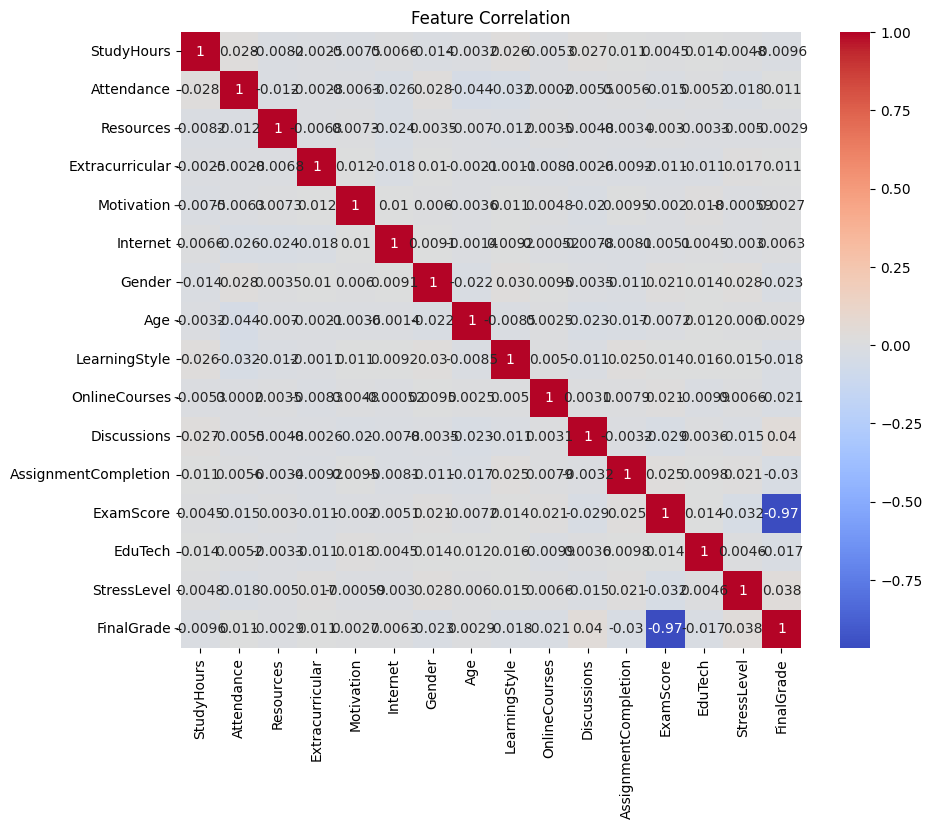

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [36]:
X = df.drop(columns=['ExamScore'])
y = df['ExamScore']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
numeric_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=20,
        max_depth=10,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech',
       'StressLevel', 'FinalGrade'],
      dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=20,
                                       random_state=42))])

In [40]:
y_pred = model.predict(X_test)

In [41]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9675272781798087
MAE: 2.6452691655947156
RMSE: 3.2154896718457837


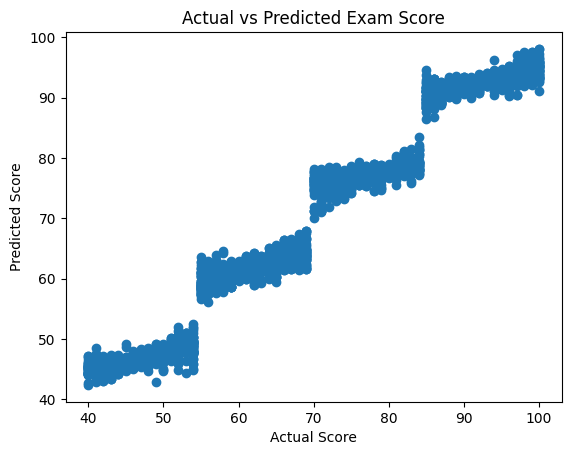

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

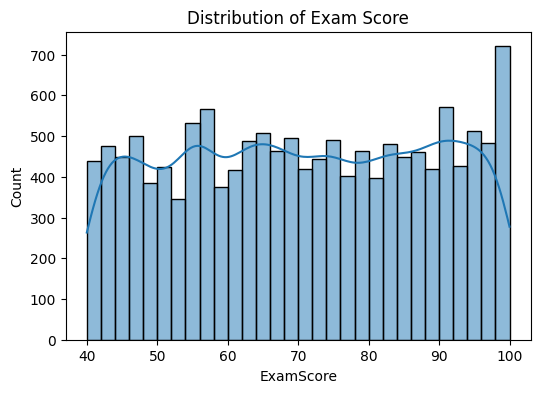

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df['ExamScore'], bins=30, kde=True)
plt.title("Distribution of Exam Score")
plt.show()

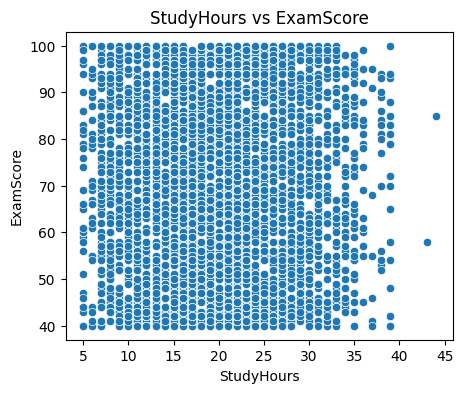

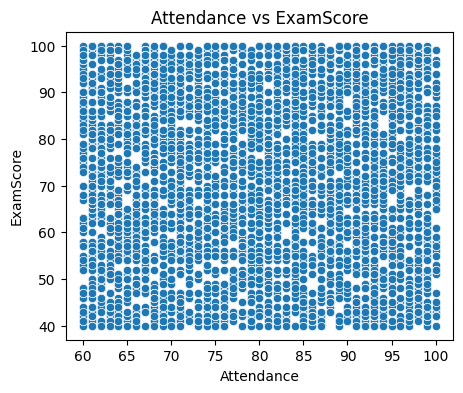

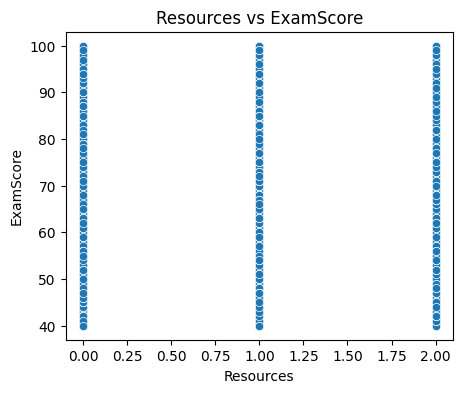

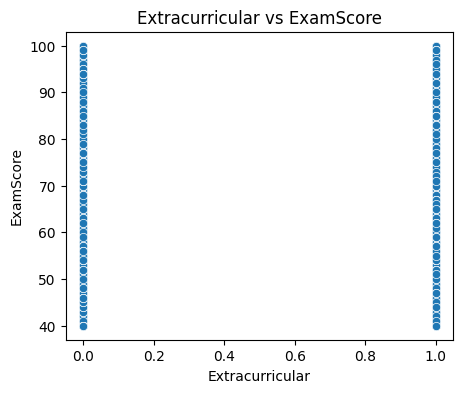

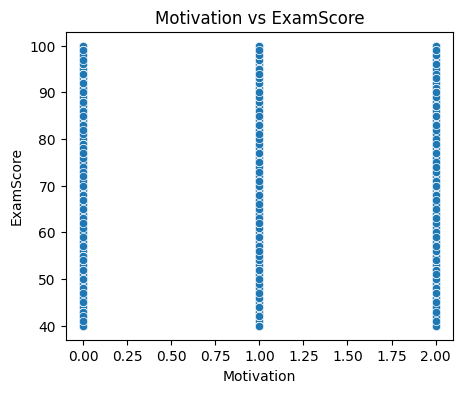

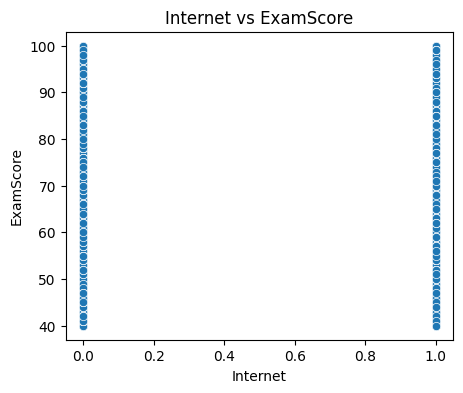

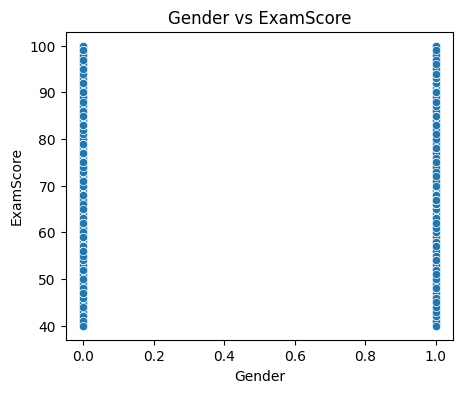

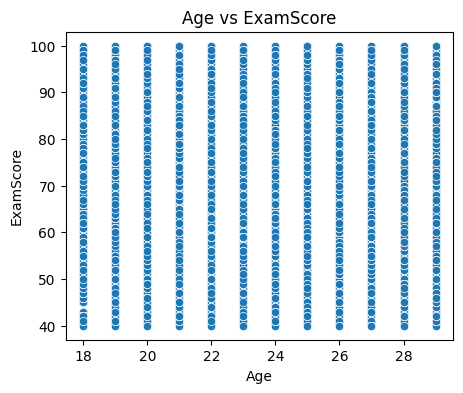

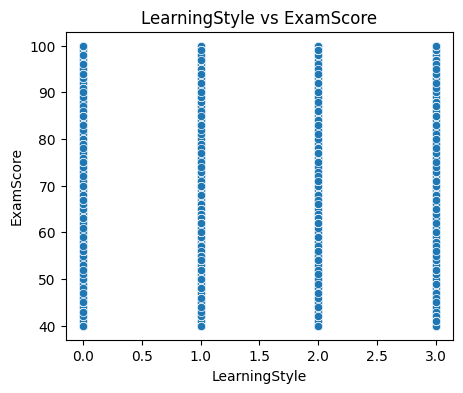

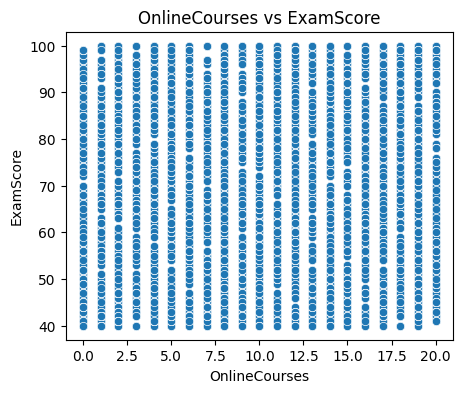

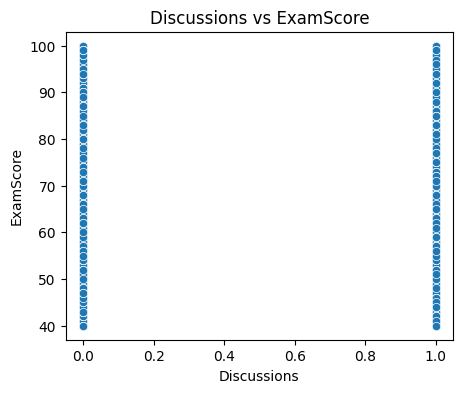

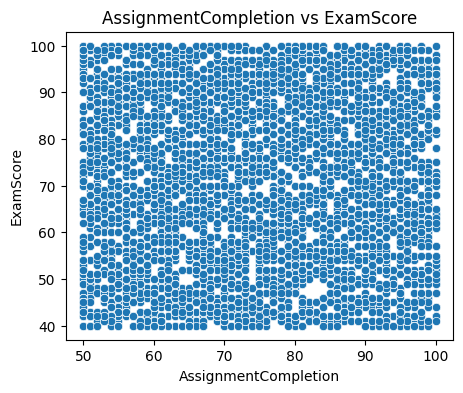

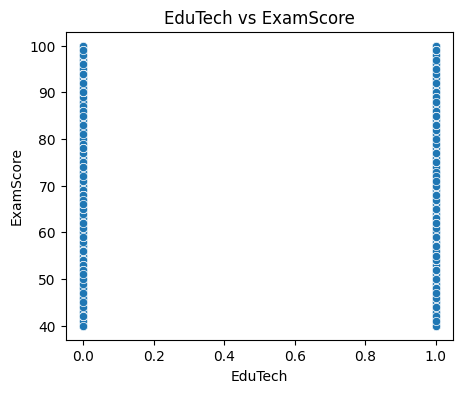

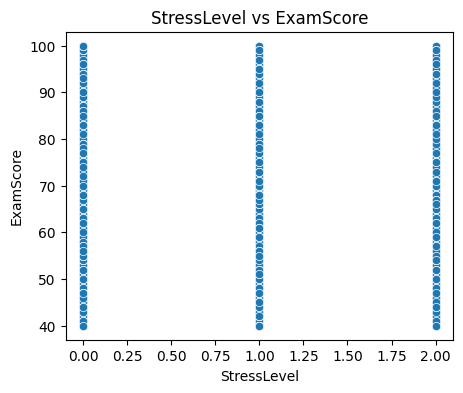

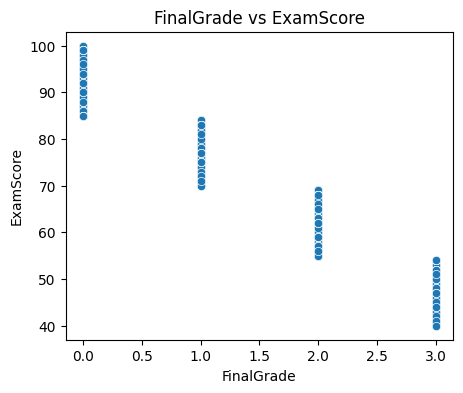

In [44]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col != 'ExamScore':
        plt.figure(figsize=(5,4))
        sns.scatterplot(x=df[col], y=df['ExamScore'])
        plt.title(f"{col} vs ExamScore")
        plt.show()

In [45]:
rf = model.named_steps['regressor']

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp

,feature,importance
14,FinalGrade,0.969684
11,AssignmentCompletion,0.006462
1,Attendance,0.005497
0,StudyHours,0.004882
9,OnlineCourses,0.004261
7,Age,0.003579
8,LearningStyle,0.001643
13,StressLevel,0.001250
6,Gender,0.000842
10,Discussions,0.000832


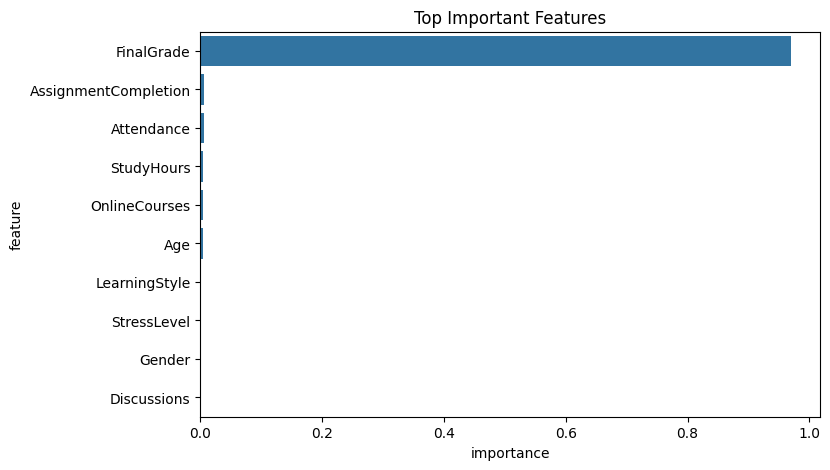

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=feat_imp.head(10))
plt.title("Top Important Features")
plt.show()

In [47]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__n_estimators': [10,20,30],
    'regressor__max_depth': [5,10],
    'regressor__min_samples_split': [2,5],
    'regressor__min_samples_leaf': [1,2]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_dist,
    n_iter=8,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech',
       'StressLevel', 'FinalGrade'],
      dtype='object'))])),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10],
                                        'regressor__min_samples_leaf': [1, 2],
                                        'regressor__min_samples_split': [2, 5],
                                        'regressor__n_estimators': [10, 20,
                                                                    30]},
                   random_state=42, scoring='r2')

In [48]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9675272781798087
MAE: 2.6452691655947156
RMSE: 3.2154896718457837


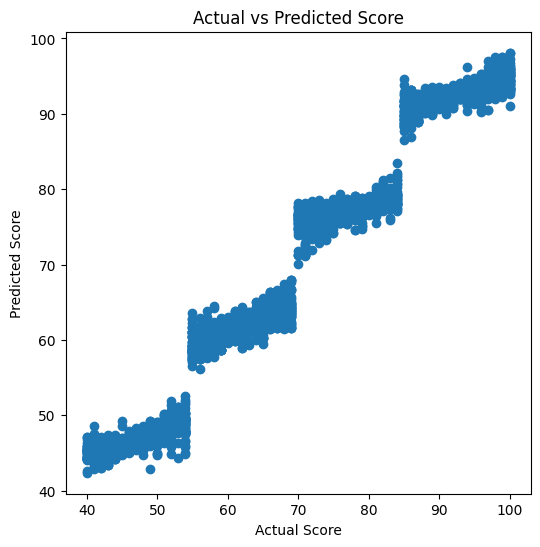

In [49]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Score")
plt.show()

In [51]:
import joblib

joblib.dump(model, "student_score_model.pkl")

['student_score_model.pkl']

In [30]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "features.pkl")

['features.pkl']